#### Machine Learning Models: Logistic Regression
Framework = CRISP-DM

Supervised Machine Learning

- Predict gender-related trends in the population by using machine learning models, such as decision trees or logistic regression. The model can be used to find causes causing gender differences or trained to predict gender based on other demographic features.


In [74]:
# Importing the required libraries:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [75]:
# Importing the Dataset 
datapop_df = pd.read_csv("irelandpopulation.csv")

In [76]:
datapop_df.head()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840
2,Population,2011,All marital status,State,Both sexes,25 - 29 years,Number,361122
3,Population,2011,All marital status,State,Both sexes,30 - 34 years,Number,393945
4,Population,2011,All marital status,State,Both sexes,35 - 39 years,Number,364261


#### Renaming some columns with the 'rename' methods because it's more appropriate.

In [77]:
datapop_df.rename(columns={'Detailed Marital Status': 'MaritalStatus', 'County and City': 'Area', 
                           'Sex': 'Gender','Age Group': 'AgeGroup', 'VALUE': 'UnitValue' }, inplace = True)
datapop_df.head(2)

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840


In [78]:
datapop_df.shape

(33480, 8)

##### Some variable names contain data entry symbols and characters, and others may necessitate data type translation. I'm going to correct this error in the data.

In this case, the marital status 'Re-married,' 'Married (first marriage),' and 'Registered same-sex civil partnership' appear to be unclear. This must be corrected.

In [79]:
print(datapop_df.MaritalStatus.unique())

['All marital status' 'Single' 'Registered same-sex civil partnership'
 'Married (first marriage)' 'Re-married' 'Separated' 'Divorced' 'Widowed']


In [80]:
datapop_df['MaritalStatus'].replace({'Re-married': 'Remarried', 'Registered same-sex civil partnership': 'Registered Same Sex',
                                     'Married (first marriage)':'Married'}, inplace=True)
print(datapop_df.MaritalStatus.nunique())

8


In [81]:
print(datapop_df.Area.unique())

['State' 'Carlow' 'Dublin City' 'Dún Laoghaire-Rathdown' 'Fingal'
 'South Dublin' 'Kildare' 'Kilkenny' 'Laois' 'Longford' 'Louth' 'Meath'
 'Offaly' 'Westmeath' 'Wexford' 'Wicklow' 'Clare'
 'Cork City and Cork County' 'Kerry' 'Limerick City and County'
 'Tipperary' 'Waterford City and County' 'Galway City' 'Galway County'
 'Leitrim' 'Mayo' 'Roscommon' 'Sligo' 'Cavan' 'Donegal' 'Monaghan']


In [82]:
datapop_df['Area'].replace({'Dún Laoghaire-Rathdown': 'Dun Laoghaire', 'Cork City and Cork County': 'Cork',
                                     'Limerick City and County':'Limerick','Waterford City and County':'Waterford'}, inplace=True)
print(datapop_df.Area.nunique())

31


#### Dropping the columns 'Statistic Label' and 'UNIT'.

For example; The 'Statistic Label' column represents the label/name of the statistic being recorded or measured.
The 'UNIT' column represent the unit of measurement for the 'Value' column. In this case it is a'Number', indicating that the value reflects a count or a numerical quantity.

In [83]:
datapop_df.drop(columns=['Statistic Label','UNIT'],inplace=True, axis=1)
datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
0,2011,All marital status,State,Both sexes,All ages,4588252
1,2011,All marital status,State,Both sexes,Under 25 years,1559840


I used `inplace=True`, `axis=1`, and the drop method to explicitly tell pandas to delete the desired columns from the DataFrame without establishing a new DataFrame.

#### Dropping some of observations (rows) 

I considered removing a few rows (observations) from the dataset. Naturally, evaluating the data's quality, applicability to the goals of the study, and effect of outliers on the analysis as a whole must come first. Before dropping any observations, I carefully considered the influence on the total dataset and ensured that the remaining data is representative and appropriate for  for addressing the research questions.

In this case, I noticed that some rows are not relevant in this analysis , such as: 'All marital status', 'Both sexes', 'All ages' and 'State', as they only add up to the overall sum of data that we already have in other observations and high outliers are the outcome of this. Dropping them can help streamline the analysis and concentrate on the most important data points.

In [84]:
datapop_df.drop(datapop_df[datapop_df['MaritalStatus'] == 'All marital status'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Gender'] == 'Both sexes'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['AgeGroup'] == 'All ages'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Area'] == 'State'].index, inplace=True)
datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
1456,2011,Single,Carlow,Male,Under 25 years,9795
1457,2011,Single,Carlow,Male,25 - 29 years,1662


In [85]:
datapop_df.shape

(17640, 6)

#### Categorical Variable Encoding:

Since many of our features involve category variables, we are converting them into numbers using the encoded methods.

Let's to separate numerical and categorical variables to analysis.

In [86]:
cat_cols=datapop_df.select_dtypes(include=['object']).columns
num_cols = datapop_df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['MaritalStatus', 'Area', 'Gender', 'AgeGroup'], dtype='object')
Numerical Variables:
['CensusYear', 'UnitValue']


As we can see,  some of the attributes are category variables. I will handle this by encoding the variables.

#### Label Encoding 

I am going to utilise Label Encoding for the categorical values 'AgeGroup' that have a natural order. The Label Encoding assigns a number value to each category.

In order to make sure that the labels are properly assigned to each category, I want to confirm the encoding mapping. Let's construct a dictionary that associates each encoded label with its associated original category in the 'AgeGroup' column. 

In [87]:
from sklearn.preprocessing import LabelEncoder
le_encoder = LabelEncoder()

In [88]:
datapop_df['AgeGroup'] = le_encoder.fit_transform(datapop_df['AgeGroup'])
unique_sorted_values = sorted(datapop_df['AgeGroup'].unique())
mapping = dict(zip(unique_sorted_values, range(len(unique_sorted_values))))
print('Encoding Mapping:')

Encoding Mapping:


I can confirm the encoding is appropriately assigned for each group by printing the mapping, ensuring that "Under 25 years" is encoded as 0, "25 - 29 years" as 1, and so on. 

for i, age_group in enumerate(unique_age_groups):
    print(f"{age_group} : {encoded_age_groups[i]}")

In [26]:
for key, value in mapping.items():
    print(f'{key} was encoded as {value}')

0 was encoded as 0
1 was encoded as 1
2 was encoded as 2
3 was encoded as 3
4 was encoded as 4
5 was encoded as 5
6 was encoded as 6
7 was encoded as 7
8 was encoded as 8
9 was encoded as 9
10 was encoded as 10
11 was encoded as 11
12 was encoded as 12
13 was encoded as 13


The mapping between the original categorical values and their associated encoded number labels appears to have worked.

In [27]:
datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
1456,2011,Single,Carlow,Male,13,9795
1457,2011,Single,Carlow,Male,0,1662


In [28]:
datapop_df.AgeGroup.unique()

array([13,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

The encoded numerical values are now replaced in the 'AgeGroup' column, enabling for additional analysis and machine learning models.

#### Binary Encoding
Let's  to convert the variable gender into a binary field, that is, replace “Male” by the value 1, Female by the value 2 and Both sexes by the value 3. The 'Gender' column in the DataFrame datapop_df can be changed in-place without generating a new DataFrame by using the `inplace=True` option in the replace function. 

In [29]:
from category_encoders import BinaryEncoder

In [30]:
dict_Gender = {'Male':1, 'Female': 2,}
datapop_df['Gender'] = datapop_df['Gender'].map(dict_Gender)
datapop_df['Gender'].replace(dict_Gender, inplace=True)
datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
1456,2011,Single,Carlow,1,13,9795
1457,2011,Single,Carlow,1,0,1662


In [31]:
datapop_df.Gender.unique()

array([1, 2], dtype=int64)

#### One-hot encoding

To encoding these two variables, 'MaritalStatus' 'and Area' I chose one-hot encoding because it may be more efficient when working with columns with multiple rows. When dealing with a large dataset, it is critical to process it efficiently. Then I used the category_encoders library, which provides memory-efficient methods for encoding categorical data. 

In [32]:
#pip install category_encoders

In [33]:
import category_encoders as ce
columns_to_encode = ['MaritalStatus', 'Area']
encoder = ce.OneHotEncoder(cols=columns_to_encode)
new_data = encoder.fit_transform(datapop_df)
new_data.head(2)

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,...,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
1456,2011,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,13,9795
1457,2011,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1662


In [34]:
new_data.shape

(17640, 41)

In [35]:
new_data.describe()

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,...,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
count,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,...,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000
mean,2016.333333,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,1.500000,6.500000,821.953288
std,4.497040,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.179511,0.179511,...,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.500014,4.031243,3561.861167
min,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,10.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,6.500000,97.000000
75%,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,389.000000
max,2022.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,13.000000,95005.000000


### Data Modeling

** Approach to be used:

*** Split the dataset into two parts: training and testing.

*** Use standardisation on the training set.

*** Transform the testing set using the parameters received from the training set.

#### Standardizing the data before or after split of training and testing data:
The values of the `UnitValue` attribute range from 0.000 to 95005.00 and `AgeGroup` from 0.000 to 13.000. Following that, I must standardize this dataset. 

The dataset will be standardized, but only once I divide it into training and testing sets. This is done in order to avoid knowledge from the testing set seeping into the training set, which could produce excessively optimistic findings and performance ratings that are not realistic. 

### Logistic Regression Model

#### Splitting the dataset into the Training set and Test set

In [36]:
from sklearn.model_selection import train_test_split

I am going to drop the 'Gender' column from the dataset and set the remaining columns the feature matrix X,while 'Gender' became the target variable y.

In [37]:
# creating features and label
X = new_data.drop('Gender', axis = 1)
y = new_data['Gender']

#### <font color='#1ABC9C'>The size for 70% train and 30 % 

In [38]:
# splitting data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

#### Feature Scaling
Standardizing entails scaling the dataset's features to a standard range. The goal of standardization the dataset is to bring all features to a similar magnitude, preventing specific features from dominating the learning process or misleading the algorithm.

In [39]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [41]:
# Predicting on the test set
y_pred = log_reg.predict(X_test)

In [42]:
# Evaluating the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.47127739984882844


In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, log_reg.predict(X_train)))

0.5120667314544866


In [44]:
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))
print(log_reg_acc)

0.47127739984882844


In [45]:
# confusion matrix
print(confusion_matrix(y_test, y_pred))

[[ 868 1832]
 [ 966 1626]]


The confusion matrix displays the number of true positives, true negatives, false positives, and false negatives.

The value '868' represents the number of true negatives (TN).

The value '1832' represents the number of false positives (FP).

The value '966' represents the number of false negatives (FN).

The value '1626' represents the number of true positives (TP).

In [46]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.47      0.32      0.38      2700
           2       0.47      0.63      0.54      2592

    accuracy                           0.47      5292
   macro avg       0.47      0.47      0.46      5292
weighted avg       0.47      0.47      0.46      5292



The classification report summarises different metrics such as precision, recall, and F1-score for each class (1 and 2), as well as total accuracy.

##### Conslusion;
The overall accuracy of roughly 0.47 shows that the model performs slightly better than random guessing. However, it is crucial to highlight that accuracy alone may not provide a whole picture, especially when working with imbalanced datasets.

From the classification report, these metrics' values indicate that the model's performance is moderate, but it may be biassed or inadequate in some areas.

I wll experiment with alternative classification algorithms to see whether they get better results for the dataset/problem.

### Random Forest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier
rand_clf = RandomForestClassifier(criterion='entropy', max_depth=11, max_features='sqrt',
                                  min_samples_leaf=2, min_samples_split=3, n_estimators=100)
rand_clf.fit(X_train, y_train)


RandomForestClassifier(criterion='entropy', max_depth=11, min_samples_leaf=2,
                       min_samples_split=3)

In [48]:
y_pred = rand_clf.predict(X_test)
# accuracy score
print(accuracy_score(y_train, rand_clf.predict(X_train)))
ran_clf_acc = accuracy_score(y_test, y_pred)
print(ran_clf_acc)

0.7322643343051506
0.43972033257747545


In [49]:
pd.DataFrame(confusion_matrix(y_test, y_pred),
             index=['neg', 'pos'], columns=['pred_neg', 'pred_pos'])

,pred_neg,pred_pos
neg,1270,1430
pos,1535,1057


This information is crucial for assessing the gender prediction model's effectiveness and determining how well it can recognise instances of each gender category.

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.45      0.47      0.46      2700
           2       0.43      0.41      0.42      2592

    accuracy                           0.44      5292
   macro avg       0.44      0.44      0.44      5292
weighted avg       0.44      0.44      0.44      5292



#### Conclusion;
With an accuracy of roughly 72.87% on the training set, the Random Forest Classifier was able to accurately predict the gender category for a sizable chunk of the dataset.
On the test data, however, the accuracy was significantly lower at about 42.84%, indicating a decline in the model's performance when applied to unknown data.

Although the Random Forest Classifier showed some promise in terms of prediction, it may have overfitted to the training set because of its noticeably reduced accuracy on the test set. For the model to perform better on untested data and become more generalizable, more feature engineering, parameter adjustment, or model modification may be required.

### Support Vector Classifier (SVC)

Based on the characteristics 'AgeGroup,' 'CensusYear,' and 'UnitValue,' the Support Vector Classifier can assist in classifying the data and offer insights into the trends and differences between the genders in the dataset. Let's apply this model

In [51]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Defining the features and target variable
X = new_data[['AgeGroup', 'CensusYear', 'UnitValue']]
y = new_data['Gender']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [52]:
# Standardizing the data
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [53]:
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train, y_train)

SVC(random_state=42)

In [54]:
y_pred = svm_classifier.predict(X_test)

In [55]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.4817

Confusion Matrix:
 [[ 677 2023]
 [ 720 1872]]


In [56]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.48      0.25      0.33      2700
           2       0.48      0.72      0.58      2592

    accuracy                           0.48      5292
   macro avg       0.48      0.49      0.45      5292
weighted avg       0.48      0.48      0.45      5292



#### Conclusion; 
The Support Vector Classifier model's total accuracy is 48.17%. This shows that for roughly 48.17% of all samples in the dataset, the gender was accurately predicted by the model.
the analysis indicates that although the model performs rather well, the recall values for the two gender categories differ noticeably. This implies that the model performs better than category 1 at accurately classifying category 2, which is the class with higher recall.

##### Table to comparing the results:

In [57]:
models = pd.DataFrame({
    'ML Models': ['Logistic Regression', 'Random Forest Classifier', 'Support Vector Classifier (SVC)'],
    'Score': [log_reg_acc, ran_clf_acc, accuracy]
})
models.sort_values(by = 'Score')

,ML Models,Score
1,Random Forest Classifier,0.439720
0,Logistic Regression,0.471277
2,Support Vector Classifier (SVC),0.481670


##### Overall conclusion:
The analysis emphasises the model's performance in predicting gender categories and the differences in its ability to correctly identify the two genders. 

This results table compares the scores produced for each model, comparing Logistic Regression and Random Forest, and I utilised the same variable pattern from the dataset for 'Gender,' we can see that Logistic Regression provided superior accuracy. When we examined the SVC result while keeping in mind that I utilised a different technique for the variables, the accuracy was pretty close to Logistic Regression. In this scenario, I would recommend continuing to apply different  models and even varying the technique to analysis to improve accuracy.

### The KNN Model

Geographic Examination: Look into how the population differs in different parts of Ireland. Is there any region that is seeing major population shifts or trends? Determine any geographical disparities or patterns that may be relevant to understanding population dynamics.

In [58]:
from sklearn.model_selection import train_test_split
# 70% training and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0) 

# Print the shape of training and testing data.
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((12348, 3), (12348,), (5292, 3), (5292,))

In [59]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

In [60]:
neighbors = np.arange(1, 9)                  # number of neighbors
train_accuracy = np.zeros(len(neighbors))  # Declare and initialise the matrix
test_accuracy = np.zeros(len(neighbors))     # Declare and initialise the matrix

In [61]:
for i,k in enumerate(neighbors):                          # for loop that checks the model for neighbor values 1, 2, 3, ..., 9
    knn = KNeighborsClassifier(n_neighbors = k)           # Initialise an object knn using KNeighborsClassifier method
    knn.fit(X_train, y_train)                      # Call fit method to implement the ML KNeighborsClassifier model
    train_accuracy[i] = knn.score(X_train, y_train)   # Save the score value in the train_accuracy array
    test_accuracy[i] = knn.score(X_test, y_test)      # Save the score value in the train_accuracy array

In [62]:
print(train_accuracy[i])
print(test_accuracy[i])

0.6236637512147716
0.5120937263794406


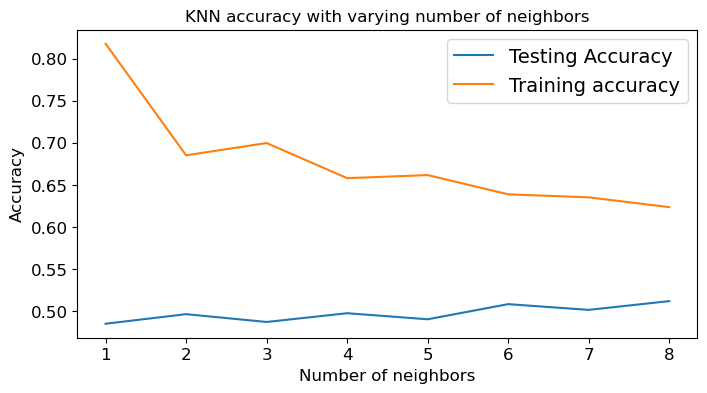

In [63]:
# Delcare the size of the array
plt.figure(figsize = (8, 4))
plt.title('KNN accuracy with varying number of neighbors', fontsize = 12)
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training accuracy')
plt.legend(prop = {'size': 14})
plt.xlabel('Number of neighbors', fontsize = 12)
plt.ylabel('Accuracy', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

In [64]:
# Declare and initialise an object 'KNeighborsClassifier' with 3 neighbors
knn = KNeighborsClassifier(n_neighbors = 9 )
knn.fit(X_train, y_train)
train_accuracy[i] = knn.score(X_train, y_train)   # Compute accuracy on the training set
test_accuracy[i] = knn.score(X_test, y_test)

##### Evaluating the Model

In [65]:
# Display the test accuracy
print(test_accuracy)

[0.48526077 0.49659864 0.48733938 0.49773243 0.49055178 0.5085034
 0.50170068 0.50680272]


##### Confusion Matrix

In [66]:
# import library for confusion matrix
from sklearn.metrics import confusion_matrix

# Predict the results by calling a method 'predict()'
prediction = knn.predict(X_test)

# Display the confusion matrix
confusion_matrix(y_test, prediction)

array([[1349, 1321],
       [1289, 1333]], dtype=int64)

In [67]:
# import the library classification_report
from sklearn.metrics import classification_report

# Display the report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           1       0.51      0.51      0.51      2670
           2       0.50      0.51      0.51      2622

    accuracy                           0.51      5292
   macro avg       0.51      0.51      0.51      5292
weighted avg       0.51      0.51      0.51      5292



### Decision Tree Classification model

	Analysis of marital status: How does the population differ based on marital status? Is there a considerable difference in population size between single people and those who are married? Examine any potential consequences of these disparities.

In [68]:
X = new_data.iloc[:, list(range(1, 8)) + [0]].values
y = new_data.iloc[:, -1].values
new_data.head(2)

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,...,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
1456,2011,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,13,9795
1457,2011,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1662


In [69]:
new_data.shape

(17640, 41)

#### Splitting the dataset into the Training set and Test set

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [71]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [72]:
#Training the Decision Tree Classification model on the Training set
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(max_depth = 3, random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [73]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
print (y_pred)

[87  0 80 ...  2 80  2]


#### Making the Confusion Matrix

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Calculate cm by calling a method named as 'confusion_matrix'
cm = confusion_matrix(y_test, y_pred)

# Call a method heatmap() to plot confusion matrix
sns.heatmap(cm, annot = True)

# print the classification_report based on y_test and y_predict
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.88      0.64       453
           1       0.00      0.00      0.00       164
           2       0.03      0.55      0.06       161
           3       0.00      0.00      0.00       114
           4       0.00      0.00      0.00       101
           5       0.00      0.00      0.00        94
           6       0.00      0.00      0.00        73
           7       0.00      0.00      0.00        57
           8       0.00      0.00      0.00        54
           9       0.00      0.00      0.00        37
          10       0.00      0.00      0.00        40
          11       0.00      0.00      0.00        38
          12       0.00      0.00      0.00        42
          13       0.00      0.00      0.00        35
          14       0.00      0.00      0.00        32
          15       0.00      0.00      0.00        20
          16       0.00      0.00      0.00        29
          17       0.00    

Error in callback <function flush_figures at 0x000001B9D3EAFCE0> (for post_execute):



KeyboardInterrupt



#### Import scikit-learn metrics module for accuracy calculation

In [ ]:
from sklearn import metrics                           
import warnings
warnings.filterwarnings('ignore') 

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,8))
from sklearn import tree
tree.plot_tree(classifier.fit(X_train, y_train)

<Figure size 1000x600 with 0 Axes>

#### Visualising the Training set results

In [56]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Training set)')
plt.xlabel('MaritalStatus_1', 'MaritalStatus_2', 'MaritalStatus_3', 'MaritalStatus_4', 'MaritalStatus_5', 'MaritalStatus_6', 'MaritalStatus_7')
plt.ylabel('UnitValue')
plt.legend()
plt.show()

ValueError: X has 2 features, but DecisionTreeClassifier is expecting 8 features as input.

#### Visualising the Test set results

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Test set)')
plt.xlabel('MaritalStatus_1', 'MaritalStatus_2', 'MaritalStatus_3', 'MaritalStatus_4', 'MaritalStatus_5', 'MaritalStatus_6', 'MaritalStatus_7')
plt.ylabel('UnitValue')
plt.legend()
plt.show()